## 1. What this notebook computes

This book has one executed notebook for every worked example. Each notebook has a
provenance file next to it, and the last line of that file records the most recent
verified check of the notebook: the tool `nbkit` executed the notebook a second time
into a scratch folder and compared everything it produced, byte for byte, with the
stored copy. This notebook collects those records and the check reports of the
Revision record into the tables of the last chapter:

- a table of every other notebook of the book: its id, title, number of checks,
  number of figures, the date, result and seconds of its last RECORDED check, and
  the section of the book where its run instructions are printed;
- the totals per chapter, and five figures of the counts and the run times;
- the step table of the Revision gate `Revision/verify_revision.sh` (the script that
  re-runs every verifier of the Revision record), with the expected wall time of
  every step, and a sixth figure;
- the index of the checks: every check of every report of the Revision record, its
  verdict and the chapters that cite it, written to a data file.

By DEFAULT this notebook does NOT re-run the other notebooks: it reads what their
provenance files record. Only when the environment variable `BOOK_RERUN_ALL` is set
to `1` does its last computing section run the check of every other notebook
again, several at a time, and print the fresh results. Notebook 23a does not list
itself: its own record changes every time it is built.

## 2. How to run this notebook

**Step 1. What this notebook does and what it needs.**

Notebook 23a (Reproducing everything: every notebook, every check, the gate) is the file
`Revision/textbook/notebooks/23a_reproduce_everything.ipynb` of the repository
Dirac_claude. It reads the recorded nbkit check of every other notebook of the book from
its provenance file (by default it does NOT re-run the other notebooks), prints a table
of every notebook with its title, number of checks, number of figures, the date, result
and seconds of its last recorded check and the section of the book where it is printed,
and draws the run times; it reads the step table of the Revision gate with the expected
wall time of every step; and it builds the index of every check of every report of the
Revision record, with its verdict and the chapters that cite it, written to a data file.
With the environment variable BOOK_RERUN_ALL set to 1 it also runs the nbkit check of
every other notebook, several at a time, into a scratch folder in the system temporary
folder, and tabulates the fresh results. It needs a computer with Windows 11, macOS or
Linux, an internet connection for the installation, the program Git, and Python 3.12 or
newer (the notebooks were built with Python 3.14.5) with these packages at exactly these
versions: numpy 2.4.6, sympy 1.14.0, mpmath 1.3.0, matplotlib 3.11.0, jupyterlab 4.4.10,
nbformat 5.10.4, nbclient 0.10.2, ipykernel 7.1.0 and nbconvert 7.16.6. The notebook
itself imports matplotlib; the other packages run Jupyter, the program that shows and
runs notebooks. It does not need Rust.

**Step 2. Install Git and Python (once per computer).**

A terminal is the window in which you type commands: on Windows the app Windows
PowerShell (or Terminal), on macOS the app Terminal (it runs the shell zsh), on Linux any
terminal (it runs the shell bash). Type every command of this section into a terminal
exactly as printed, one line at a time, and press Enter after each line.

Windows: download Git from https://git-scm.com/download/win and install it with the
default choices. Download Python from https://www.python.org/downloads/ and run the
installer; in its first window tick the box "Add python.exe to PATH" before you click
"Install Now".

macOS: download Python from https://www.python.org/downloads/ and run the installer. Then
open the app Terminal and run this command, which installs Git and the compiler tools:

macOS (zsh):

    xcode-select --install

Linux (Debian or Ubuntu; other distributions have packages of the same names): run these
two commands:

Linux (bash):

    sudo apt update
    sudo apt install git python3 python3-venv

Then close the terminal and open a NEW one (a terminal opened before the installation
does not know the new programs), and check the version of Python; it must print 3.12 or a
higher number:

Windows (PowerShell):

    py -3 --version

macOS (zsh) and Linux (bash):

    python3 --version

If an older Linux prints a lower number (Ubuntu 22.04 has Python 3.10), install Python
3.12 with the following three commands, and in Step 3 type `python3.12` instead of
`python3` in the command that creates the environment:

Linux (bash), only when the version is too low:

    sudo add-apt-repository ppa:deadsnakes/ppa
    sudo apt update
    sudo apt install python3.12 python3.12-venv

**Step 3. Get the repository and install the packages (once per computer).**

The commands below download the repository (a few hundred megabytes; the folder then
needs up to about 1 GB of disk space) into the folder Dirac_claude inside your home
folder, create a private Python environment in the folder dirac-book-env inside your home
folder (a private environment is a folder with its own copy of Python and of the
packages, so that nothing else on your computer is changed), activate it (from then on
the commands `python` and `jupyter` typed in this terminal are those of the environment,
and the prompt starts with (dirac-book-env)), and install the packages at the pinned
versions (this downloads about 90 MB and takes a few minutes; the environment takes about
400 MB of disk space). If you have done this step before, for this or for another
notebook, skip it and go to Step 4; to get the newest version of the repository, run `git
pull` in the repository folder after Step 4.

Windows (PowerShell):

    cd $HOME
    git clone https://github.com/once-ere/Dirac_claude.git
    py -3 -m venv "$HOME\dirac-book-env"
    Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
    & "$HOME\dirac-book-env\Scripts\Activate.ps1"
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

The line with `Set-ExecutionPolicy` allows PowerShell to run the activation script in
this one window only; it changes nothing permanently.

macOS (zsh):

    cd ~
    git clone https://github.com/once-ere/Dirac_claude.git
    python3 -m venv ~/dirac-book-env
    source ~/dirac-book-env/bin/activate
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

Linux (bash):

    cd ~
    git clone https://github.com/once-ere/Dirac_claude.git
    python3 -m venv ~/dirac-book-env
    source ~/dirac-book-env/bin/activate
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

**Step 4. In every new terminal: activate the environment and go into the repository
folder.**

Every later step starts in the repository folder with the environment active. Run these
lines whenever you open a new terminal (they do no harm if the environment is already
active):

Windows (PowerShell):

    Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
    & "$HOME\dirac-book-env\Scripts\Activate.ps1"
    cd "$HOME\Dirac_claude"

macOS (zsh) and Linux (bash):

    source ~/dirac-book-env/bin/activate
    cd ~/Dirac_claude

**Step 5. Run the notebook in JupyterLab.**

In the repository folder, with the environment active, run these two lines (the first one
goes into the folder of the notebooks):

Windows, macOS and Linux:

    cd Revision/textbook/notebooks
    jupyter lab 23a_reproduce_everything.ipynb

JupyterLab opens in your web browser and shows the notebook (if no browser window opens,
copy the address that starts with `http://localhost:8888/lab` from the terminal into the
address bar of your browser). The name at the top right of the notebook must read Python
3 (ipykernel). Choose the menu Run > Run All Cells. While a cell runs, the label to its
left shows `[*]`; when it has finished, the label shows a number. The notebook has
finished when the last code cell shows a number; this takes about 10 seconds on a typical
laptop. Scroll to the end and compare the last printed lines with the lines in the step
"What the notebook writes and what you must see" below. To keep the results, save the
notebook (menu File > Save Notebook). To stop JupyterLab, choose the menu File > Shut
Down, or press Ctrl+C twice in the terminal.

**Step 6. Or run the notebook without a browser (headless).**

In the repository folder, with the environment active, run:

Windows, macOS and Linux:

    cd Revision/textbook/notebooks
    jupyter nbconvert --to notebook --execute --inplace 23a_reproduce_everything.ipynb

This runs every cell from the top to the bottom and saves the results into the notebook
file. A failed check stops it with an error message that contains AssertionError and the
name of the check. If the command ends with a line that starts with `[NbConvertApp]
Writing` and shows no error, every check passed; open the notebook with `jupyter lab
23a_reproduce_everything.ipynb` (in the same folder, without running the cells again) to
read the printed lines and see the figures.

**Step 7. What the notebook writes and what you must see.**

The notebook writes (or overwrites) these files:

- `Revision/textbook/figures/23a.captions.json`
- `Revision/textbook/figures/23a_1_check_time_per_notebook.png`
- `Revision/textbook/figures/23a_2_cumulative_check_time.png`
- `Revision/textbook/figures/23a_3_checks_per_chapter.png`
- `Revision/textbook/figures/23a_4_figures_per_chapter.png`
- `Revision/textbook/figures/23a_5_check_time_per_chapter.png`
- `Revision/textbook/figures/23a_6_gate_step_times.png`
- `Revision/textbook/data/23a_notebooks.csv`
- `Revision/textbook/data/23a_check_index.csv`

It changes no other file of the repository; running it headless or saving it in
JupyterLab also rewrites the notebook file itself. It does not use the internet while it
runs. The files it writes are the same files that are stored in the repository (on
another computer a figure may differ in a few bytes, which is harmless). To get the
stored versions back, run this command in the repository folder (it also undoes every
change you made yourself in the folder Revision/textbook):

Windows, macOS and Linux:

    git checkout -- Revision/textbook

Every check of the notebook prints a line that starts with PASS. At the end of the
notebook (the output of its last code cell) you must see exactly these lines:

    PASS every file this notebook writes exists
    ALL 10 CHECKS PASSED (notebook 23a)

and the notebook must show 6 figures below the cells that draw them.

**Step 8. If something goes wrong.**

- "ModuleNotFoundError: No module named ..." in the notebook: JupyterLab was started
  without the environment. Stop it (menu File > Shut Down), do Step 4, and start it
  again. If the error remains, another Python installation has registered its own kernel
  called python3; with the environment active, run the following command and start
  JupyterLab again:

      python -m ipykernel install --user --name python3

- "FileNotFoundError: The repository folder was not found": the notebook was opened from
  a copy outside the repository. Open the file
  `Revision/textbook/notebooks/23a_reproduce_everything.ipynb` inside the folder
  Dirac_claude.
- "fatal: destination path 'Dirac_claude' already exists" in Step 3: the repository was
  downloaded before; skip the line with `git clone`.
- Windows: "running scripts is disabled on this system": run the line with
  `Set-ExecutionPolicy` and then the activation line again. "py is not recognized": use
  `python` instead of `py -3`; "python is not recognized": install Python again and tick
  "Add python.exe to PATH".
- Linux: "ensurepip is not available" when the environment is created: run `sudo apt
  install python3-venv` and repeat Step 3.
- "jupyter is not recognized" or "command not found: jupyter": the environment is not
  active; do Step 4. If the environment is active and the message stays, the programs
  jupyter-lab and jupyter-nbconvert are not in the folders where the terminal looks for
  programs (`python -m jupyter` does not help then: it has to find the same programs).
  Start them through Python itself, in the folder of the notebook: the first command
  below does what `jupyter lab` does, the second what the headless command does:

      python -m jupyterlab 23a_reproduce_everything.ipynb
      python -m nbconvert --execute --inplace 23a_reproduce_everything.ipynb

- Windows: the headless run prints a RuntimeWarning that mentions the "Proactor event
  loop" and zmq: this is a message of the package pyzmq, not an error; the run continues
  normally.
- A red box with "Matplotlib is building the font cache; this may take a moment." in the
  first run after the installation: this is a message, not an error; the run continues
  and the message does not come again.
- An AssertionError names a check that failed: choose the menu Kernel > Restart Kernel
  and Run All Cells; if it fails again, install the packages again with the pip commands
  of Step 3, because a different package version can change the last digits of a result.
- The last section prints that no other notebook was re-run: that is the default. To
  re-run every other notebook, set the environment variable BOOK_RERUN_ALL to 1 in the
  terminal, start JupyterLab or the headless run from that same terminal, and run the
  notebook again. Unset it afterwards.

      $env:BOOK_RERUN_ALL = "1"      (Windows PowerShell)
      export BOOK_RERUN_ALL=1          (macOS zsh, Linux bash)

- With BOOK_RERUN_ALL set to 1, the notebooks that run a Rust program fail: install Rust
  from https://rustup.rs, open a new terminal, activate the environment and run the
  notebook again; the first build of each Rust program takes a few minutes.

The first code cell below (the set-up cell) repeats these instructions as comments; then
it imports the packages, finds the repository folder and defines the helpers
`save_figure` (saves a figure and shows it), `check` (stops with an AssertionError when a
check fails, prints a PASS line when it passes), `report` (prints a key number as a
RESULT line) and `all_checks_passed` (prints the last line).

In [1]:
# HOW TO RUN NOTEBOOK 23a (the complete instructions)
#
# STEP 1. WHAT THIS NOTEBOOK DOES AND WHAT IT NEEDS.
#
# Notebook 23a (Reproducing everything: every notebook, every check, the gate) is the
# file Revision/textbook/notebooks/23a_reproduce_everything.ipynb of the repository
# Dirac_claude. It reads the recorded nbkit check of every other notebook of the book
# from its provenance file (by default it does NOT re-run the other notebooks), prints a
# table of every notebook with its title, number of checks, number of figures, the date,
# result and seconds of its last recorded check and the section of the book where it is
# printed, and draws the run times; it reads the step table of the Revision gate with the
# expected wall time of every step; and it builds the index of every check of every
# report of the Revision record, with its verdict and the chapters that cite it, written
# to a data file. With the environment variable BOOK_RERUN_ALL set to 1 it also runs the
# nbkit check of every other notebook, several at a time, into a scratch folder in the
# system temporary folder, and tabulates the fresh results. It needs a computer with
# Windows 11, macOS or Linux, an internet connection for the installation, the program
# Git, and Python 3.12 or newer (the notebooks were built with Python 3.14.5) with these
# packages at exactly these versions: numpy 2.4.6, sympy 1.14.0, mpmath 1.3.0, matplotlib
# 3.11.0, jupyterlab 4.4.10, nbformat 5.10.4, nbclient 0.10.2, ipykernel 7.1.0 and
# nbconvert 7.16.6. The notebook itself imports matplotlib; the other packages run
# Jupyter, the program that shows and runs notebooks. It does not need Rust.
#
# STEP 2. INSTALL GIT AND PYTHON (ONCE PER COMPUTER).
#
# A terminal is the window in which you type commands: on Windows the app Windows
# PowerShell (or Terminal), on macOS the app Terminal (it runs the shell zsh), on Linux
# any terminal (it runs the shell bash). Type every command of this section into a
# terminal exactly as printed, one line at a time, and press Enter after each line.
#
# Windows: download Git from https://git-scm.com/download/win and install it with the
# default choices. Download Python from https://www.python.org/downloads/ and run the
# installer; in its first window tick the box "Add python.exe to PATH" before you click
# "Install Now".
#
# macOS: download Python from https://www.python.org/downloads/ and run the installer.
# Then open the app Terminal and run this command, which installs Git and the compiler
# tools:
#
# macOS (zsh):
#     xcode-select --install
#
# Linux (Debian or Ubuntu; other distributions have packages of the same names): run
# these two commands:
#
# Linux (bash):
#     sudo apt update
#     sudo apt install git python3 python3-venv
#
# Then close the terminal and open a NEW one (a terminal opened before the installation
# does not know the new programs), and check the version of Python; it must print 3.12 or
# a higher number:
#
# Windows (PowerShell):
#     py -3 --version
#
# macOS (zsh) and Linux (bash):
#     python3 --version
#
# If an older Linux prints a lower number (Ubuntu 22.04 has Python 3.10), install Python
# 3.12 with the following three commands, and in Step 3 type python3.12 instead of
# python3 in the command that creates the environment:
#
# Linux (bash), only when the version is too low:
#     sudo add-apt-repository ppa:deadsnakes/ppa
#     sudo apt update
#     sudo apt install python3.12 python3.12-venv
#
# STEP 3. GET THE REPOSITORY AND INSTALL THE PACKAGES (ONCE PER COMPUTER).
#
# The commands below download the repository (a few hundred megabytes; the folder then
# needs up to about 1 GB of disk space) into the folder Dirac_claude inside your home
# folder, create a private Python environment in the folder dirac-book-env inside your
# home folder (a private environment is a folder with its own copy of Python and of the
# packages, so that nothing else on your computer is changed), activate it (from then on
# the commands python and jupyter typed in this terminal are those of the environment,
# and the prompt starts with (dirac-book-env)), and install the packages at the pinned
# versions (this downloads about 90 MB and takes a few minutes; the environment takes
# about 400 MB of disk space). If you have done this step before, for this or for another
# notebook, skip it and go to Step 4; to get the newest version of the repository, run
# git pull in the repository folder after Step 4.
#
# Windows (PowerShell):
#     cd $HOME
#     git clone https://github.com/once-ere/Dirac_claude.git
#     py -3 -m venv "$HOME\dirac-book-env"
#     Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
#     & "$HOME\dirac-book-env\Scripts\Activate.ps1"
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# The line with Set-ExecutionPolicy allows PowerShell to run the activation script in
# this one window only; it changes nothing permanently.
#
# macOS (zsh):
#     cd ~
#     git clone https://github.com/once-ere/Dirac_claude.git
#     python3 -m venv ~/dirac-book-env
#     source ~/dirac-book-env/bin/activate
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# Linux (bash):
#     cd ~
#     git clone https://github.com/once-ere/Dirac_claude.git
#     python3 -m venv ~/dirac-book-env
#     source ~/dirac-book-env/bin/activate
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# STEP 4. IN EVERY NEW TERMINAL: ACTIVATE THE ENVIRONMENT AND GO INTO THE REPOSITORY
# FOLDER.
#
# Every later step starts in the repository folder with the environment active. Run these
# lines whenever you open a new terminal (they do no harm if the environment is already
# active):
#
# Windows (PowerShell):
#     Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
#     & "$HOME\dirac-book-env\Scripts\Activate.ps1"
#     cd "$HOME\Dirac_claude"
#
# macOS (zsh) and Linux (bash):
#     source ~/dirac-book-env/bin/activate
#     cd ~/Dirac_claude
#
# STEP 5. RUN THE NOTEBOOK IN JUPYTERLAB.
#
# In the repository folder, with the environment active, run these two lines (the first
# one goes into the folder of the notebooks):
#
# Windows, macOS and Linux:
#     cd Revision/textbook/notebooks
#     jupyter lab 23a_reproduce_everything.ipynb
#
# JupyterLab opens in your web browser and shows the notebook (if no browser window
# opens, copy the address that starts with http://localhost:8888/lab from the terminal
# into the address bar of your browser). The name at the top right of the notebook must
# read Python 3 (ipykernel). Choose the menu Run > Run All Cells. While a cell runs, the
# label to its left shows [*]; when it has finished, the label shows a number. The
# notebook has finished when the last code cell shows a number; this takes about 10
# seconds on a typical laptop. Scroll to the end and compare the last printed lines with
# the lines in the step "What the notebook writes and what you must see" below. To keep
# the results, save the notebook (menu File > Save Notebook). To stop JupyterLab, choose
# the menu File > Shut Down, or press Ctrl+C twice in the terminal.
#
# STEP 6. OR RUN THE NOTEBOOK WITHOUT A BROWSER (HEADLESS).
#
# In the repository folder, with the environment active, run:
#
# Windows, macOS and Linux:
#     cd Revision/textbook/notebooks
#     jupyter nbconvert --to notebook --execute --inplace 23a_reproduce_everything.ipynb
#
# This runs every cell from the top to the bottom and saves the results into the notebook
# file. A failed check stops it with an error message that contains AssertionError and
# the name of the check. If the command ends with a line that starts with [NbConvertApp]
# Writing and shows no error, every check passed; open the notebook with jupyter lab
# 23a_reproduce_everything.ipynb (in the same folder, without running the cells again) to
# read the printed lines and see the figures.
#
# STEP 7. WHAT THE NOTEBOOK WRITES AND WHAT YOU MUST SEE.
#
# The notebook writes (or overwrites) these files:
#
# - Revision/textbook/figures/23a.captions.json
# - Revision/textbook/figures/23a_1_check_time_per_notebook.png
# - Revision/textbook/figures/23a_2_cumulative_check_time.png
# - Revision/textbook/figures/23a_3_checks_per_chapter.png
# - Revision/textbook/figures/23a_4_figures_per_chapter.png
# - Revision/textbook/figures/23a_5_check_time_per_chapter.png
# - Revision/textbook/figures/23a_6_gate_step_times.png
# - Revision/textbook/data/23a_notebooks.csv
# - Revision/textbook/data/23a_check_index.csv
#
# It changes no other file of the repository; running it headless or saving it in
# JupyterLab also rewrites the notebook file itself. It does not use the internet while
# it runs. The files it writes are the same files that are stored in the repository (on
# another computer a figure may differ in a few bytes, which is harmless). To get the
# stored versions back, run this command in the repository folder (it also undoes every
# change you made yourself in the folder Revision/textbook):
#
# Windows, macOS and Linux:
#     git checkout -- Revision/textbook
#
# Every check of the notebook prints a line that starts with PASS. At the end of the
# notebook (the output of its last code cell) you must see exactly these lines:
#
#     PASS every file this notebook writes exists
#     ALL 10 CHECKS PASSED (notebook 23a)
#
# and the notebook must show 6 figures below the cells that draw them.
#
# STEP 8. IF SOMETHING GOES WRONG.
#
# - "ModuleNotFoundError: No module named ..." in the notebook: JupyterLab was started
#   without the environment. Stop it (menu File > Shut Down), do Step 4, and start it
#   again. If the error remains, another Python installation has registered its own
#   kernel called python3; with the environment active, run the following command and
#   start JupyterLab again:
#     python -m ipykernel install --user --name python3
# - "FileNotFoundError: The repository folder was not found": the notebook was opened
#   from a copy outside the repository. Open the file
#   Revision/textbook/notebooks/23a_reproduce_everything.ipynb inside the folder
#   Dirac_claude.
# - "fatal: destination path 'Dirac_claude' already exists" in Step 3: the repository was
#   downloaded before; skip the line with git clone.
# - Windows: "running scripts is disabled on this system": run the line with
#   Set-ExecutionPolicy and then the activation line again. "py is not recognized": use
#   python instead of py -3; "python is not recognized": install Python again and tick
#   "Add python.exe to PATH".
# - Linux: "ensurepip is not available" when the environment is created: run sudo apt
#   install python3-venv and repeat Step 3.
# - "jupyter is not recognized" or "command not found: jupyter": the environment is not
#   active; do Step 4. If the environment is active and the message stays, the programs
#   jupyter-lab and jupyter-nbconvert are not in the folders where the terminal looks for
#   programs (python -m jupyter does not help then: it has to find the same programs).
#   Start them through Python itself, in the folder of the notebook: the first command
#   below does what jupyter lab does, the second what the headless command does:
#     python -m jupyterlab 23a_reproduce_everything.ipynb
#     python -m nbconvert --execute --inplace 23a_reproduce_everything.ipynb
# - Windows: the headless run prints a RuntimeWarning that mentions the "Proactor event
#   loop" and zmq: this is a message of the package pyzmq, not an error; the run
#   continues normally.
# - A red box with "Matplotlib is building the font cache; this may take a moment." in
#   the first run after the installation: this is a message, not an error; the run
#   continues and the message does not come again.
# - An AssertionError names a check that failed: choose the menu Kernel > Restart Kernel
#   and Run All Cells; if it fails again, install the packages again with the pip
#   commands of Step 3, because a different package version can change the last digits of
#   a result.
# - The last section prints that no other notebook was re-run: that is the default. To
#   re-run every other notebook, set the environment variable BOOK_RERUN_ALL to 1 in the
#   terminal, start JupyterLab or the headless run from that same terminal, and run the
#   notebook again. Unset it afterwards.
#     $env:BOOK_RERUN_ALL = "1"      (Windows PowerShell)
#     export BOOK_RERUN_ALL=1          (macOS zsh, Linux bash)
# - With BOOK_RERUN_ALL set to 1, the notebooks that run a Rust program fail: install
#   Rust from https://rustup.rs, open a new terminal, activate the environment and run
#   the notebook again; the first build of each Rust program takes a few minutes.
#
# ---------------------------------------------------------------------------------------
# =======================================================================================
# THE SET-UP (the same in every notebook of this book; it computes no physics)
# =======================================================================================
import json  # reads and writes JSON files (text files that hold names and numbers)
import os  # reads the environment variable TEXTBOOK_OUTPUT_ROOT (explained below)
import textwrap  # breaks long printed text into lines of at most 89 characters
from pathlib import Path  # file and folder paths that work on Windows, macOS and Linux

import matplotlib  # the plotting package
import matplotlib.pyplot as plt  # its drawing functions, called plt by convention
from IPython.display import Image, display  # shows a saved picture below a cell

NOTEBOOK_ID = "23a"  # this notebook: chapter 23, example a


def find_repository_root():
    """Return the repository folder (Dirac_claude).

    Jupyter runs a notebook in the folder that holds it.  Starting there, go up one
    folder at a time until a folder contains Revision/textbook/requirements.txt (the
    list of the book's packages); that folder is the repository."""
    here = Path.cwd().resolve()  # the folder in which this notebook runs
    for folder in [here, *here.parents]:  # this folder, its parent, its grandparent ...
        if (folder / "Revision" / "textbook" / "requirements.txt").is_file():
            return folder
    raise FileNotFoundError(
        "The repository folder was not found: open this notebook inside the folder "
        "Revision/textbook/notebooks of the repository Dirac_claude")


# The repository folder.  It is never printed: it differs from computer to computer,
# and the printed output of a notebook must not.
REPO = find_repository_root()
# Every file is WRITTEN below OUTPUT_ROOT.  OUTPUT_ROOT is the repository folder unless
# the environment variable TEXTBOOK_OUTPUT_ROOT names another folder; the book's
# checking tool sets it, so that a check run writes into a scratch folder instead.
OUTPUT_ROOT = Path(os.environ.get("TEXTBOOK_OUTPUT_ROOT", str(REPO)))


def repository_file(relative):
    """The path of the repository file relative, for READING (a Revision record)."""
    return REPO / relative


def output_file(relative):
    """The path at which to WRITE the repository file relative (its folder is made)."""
    path = OUTPUT_ROOT / relative
    path.parent.mkdir(parents=True, exist_ok=True)
    return path


def say(text):
    """Print text in lines of at most 89 characters (the width of a page of the book)."""
    print(textwrap.fill(str(text), width=89, subsequent_indent="    "))


matplotlib.rcdefaults()  # ignore personal matplotlib settings: same figures everywhere
plt.rcParams.update({"figure.figsize": (7.0, 4.2), "font.size": 10.0,
                     "axes.grid": True, "grid.alpha": 0.3})

FIGURE_FOLDER = "Revision/textbook/figures"  # where the figures are saved
CAPTION_FILE = f"{FIGURE_FOLDER}/{NOTEBOOK_ID}.captions.json"  # their captions
FIGURE_NUMBERS = {}  # figure name -> its number k (file name <id>_<k>_<name>.png)
CAPTIONS = {}  # figure file name -> caption, written to CAPTION_FILE after every figure
# Start with an empty captions file ({} is an empty JSON dictionary); save_figure fills
# it.  newline="\n" writes the same line ends on Windows, macOS and Linux.
output_file(CAPTION_FILE).write_text("{}\n", encoding="utf-8", newline="\n")


def save_figure(fig, name, caption):
    """Save the figure fig as Revision/textbook/figures/<id>_<k>_<name>.png, record its
    caption in CAPTION_FILE, show the saved picture below the cell and close the figure.
    k counts the figures of the notebook 1, 2, 3, ...; a cell run again keeps its k."""
    number = FIGURE_NUMBERS.setdefault(name, len(FIGURE_NUMBERS) + 1)
    file_name = f"{NOTEBOOK_ID}_{number}_{name}.png"
    relative = f"{FIGURE_FOLDER}/{file_name}"
    # dpi=150: 150 dots per inch.  bbox_inches="tight": cut away the empty margin.
    # metadata={"Software": None}: no program name is stored in the PNG file, so that
    # every run writes exactly the same bytes.
    fig.savefig(output_file(relative), dpi=150, bbox_inches="tight",
                metadata={"Software": None})
    plt.close(fig)  # forget the figure, so that Jupyter does not draw it a second time
    CAPTIONS[file_name] = caption
    output_file(CAPTION_FILE).write_text(
        json.dumps(CAPTIONS, indent=1, sort_keys=True) + "\n", encoding="utf-8",
        newline="\n")
    display(Image(filename=str(output_file(relative))),
            metadata={"textbook_figure": file_name})  # the saved picture itself
    say(f"Figure {NOTEBOOK_ID}.{number} saved as {relative}")


PASSED = []  # the names of the checks that passed, in order


def check(condition, name, record=None):
    """A check.  If condition is False, stop with an AssertionError that names the
    check (an if statement is used instead of assert, because python -O would skip an
    assert).  Otherwise print "PASS <name>" and, when the check reproduces a Revision
    record, a second line naming the record file and its check."""
    if not condition:
        raise AssertionError(f"check failed: {name}")
    PASSED.append(name)
    say(f"PASS {name}")
    if record is not None:
        say(f"     reproduces {record}")


def report(label, value, unit=""):
    """Print a key number as a line "RESULT <label> = <value> <unit>"."""
    say(f"RESULT {label} = {value}" + (f" {unit}" if unit else ""))


def all_checks_passed():
    """Print the last line of the notebook: how many checks passed."""
    print(f"ALL {len(PASSED)} CHECKS PASSED (notebook {NOTEBOOK_ID})")


say(f"Set-up of notebook {NOTEBOOK_ID} complete: repository folder found, helpers "
    "defined.")

Set-up of notebook 23a complete: repository folder found, helpers defined.


## 3. The words used in this notebook

- **Builder**: the Python file `Revision/textbook/notebooks/src/NNx_name.py` that
  defines the cells of notebook NNx; the tool `nbkit` builds the notebook from it.
- **nbkit check**: the command `python Revision/textbook/tools/nbkit.py check
  BUILDER`. It executes the notebook again into a scratch folder and compares the
  notebook, every file it writes and its provenance file byte for byte with the
  stored ones; it prints `check_NNx=PASSED` or `check_NNx=FAILED`.
- **Provenance file**: `NNx_name.PROVENANCE.md`, next to each notebook; its last line,
  an HTML comment that starts with the word `nbkit-record`, holds the measured facts
  of the last verified run, written in JSON.
- **JSON**: a text format for numbers, strings, lists and tables of named values.
- **CSV**: a text table, one row per line, the cells separated by commas.
- **Wall time**: the time on a clock on the wall, from start to finish, in seconds.
- **Report**: a JSON file of the Revision record that holds a list (or table) of named
  checks, each with a verdict such as PASS.
- **Gate**: the script `Revision/verify_revision.sh` (and its twin
  `Revision/verify_revision.ps1`) that re-runs every verifier and checker of the
  Revision record in dependency order.
- **Cite**: a chapter cites a check when one paragraph of the chapter, or the output
  of one code cell of one of the chapter's notebooks, names both the check and the
  file name of its report.
- **Environment variable**: a named text value that a terminal hands to every
  program it starts; `BOOK_RERUN_ALL` is one.

## 4. The physical and mathematical situation

Nothing in this notebook is physics: it is bookkeeping, and every number it prints is
COUNTED from files of the repository. The seconds are those MEASURED by nbkit on the
development machine (Windows 11, 24 threads) and recorded in the provenance files;
the gate's times are the EXPECTED wall times written in its step table. On another
computer the times differ, but the counts, the verdicts and the results do not.

## 5. The provenance record of every notebook

The next cell reads every provenance file of the folder of notebooks, except the
one of this notebook. From each it takes the title, the number of checks (from the
line `ALL n CHECKS PASSED`) and the recorded check; from the notebook's caption file
it counts the figures. It then checks that builders and provenance files match one
to one, that every recorded check passed, and that every figure file exists.

In [2]:
import csv  # reads and writes comma-separated tables
import re  # regular expressions: patterns that find pieces of text

NOTEBOOKS = repository_file("Revision/textbook/notebooks")  # notebooks and records
RECORD = re.compile(r"nbkit-record (\{.*\}) -->")  # the record line
ALL_LINE = re.compile(r"ALL (\d+) CHECKS PASSED")  # the last line of a notebook
TITLE = re.compile(r"^# Provenance of Notebook \w+: (.+)$", re.MULTILINE)


def by_name(paths):
    """Sort paths by their repository-relative name, the same on every system."""
    return sorted(paths, key=lambda path: path.relative_to(REPO).as_posix())


ROWS = []  # one dictionary per notebook
for path in by_name(NOTEBOOKS.glob("*.PROVENANCE.md")):
    name = path.name.removesuffix(".PROVENANCE.md")  # e.g. 00a_check_installation
    if name.startswith(NOTEBOOK_ID):
        continue  # this notebook's own record changes whenever it is built
    text = path.read_text(encoding="utf-8")
    record = json.loads(RECORD.search(text).group(1))
    captions = json.loads(repository_file(
        f"{FIGURE_FOLDER}/{name[:3]}.captions.json").read_text(encoding="utf-8"))
    ROWS.append({"id": name[:3], "chapter": int(name[:2]), "name": name,
                 "title": TITLE.search(text).group(1),
                 "checks": int(ALL_LINE.search(text).group(1)),
                 "figures": len(captions), "figure_files": sorted(captions),
                 "date": record["check"]["date"],
                 "result": record["check"]["result"],
                 "seconds": record["check"]["seconds"],
                 "builder": f"Revision/textbook/notebooks/src/{name}.py"})

builders = [path.stem for path in by_name(NOTEBOOKS.glob("src/*.py"))
            if not path.stem.startswith(NOTEBOOK_ID)]
say(f"{len(ROWS)} provenance files read, {len(builders)} builders found.")
check([row["name"] for row in ROWS] == builders,
      "every builder has a provenance file and every provenance file a builder")
check(all(row["result"] == "passed" for row in ROWS),
      "the last recorded nbkit check of every notebook passed")
check(all(repository_file(f"{FIGURE_FOLDER}/{figure}").is_file()
          for row in ROWS for figure in row["figure_files"]),
      "every figure named in a caption file exists")

90 provenance files read, 90 builders found.
PASS every builder has a provenance file and every provenance file a builder
PASS the last recorded nbkit check of every notebook passed
PASS every figure named in a caption file exists


## 6. Where each notebook is printed in the book

A notebook is placed in its chapter by a marker line: an HTML comment that holds the
word `NOTEBOOK` and the notebook's id, such as `NOTEBOOK 03b`. The book's assembler
replaces the marker by two new sections: the run instructions,
numbered one more than the last section heading `### N.M` before the marker, and
then the complete text of the notebook. The next cell reads chapters 0 to 22 (this
chapter 23 is left out, so that its own text cannot change the results), finds
every marker and the heading before it, and checks that every notebook is placed
exactly once, in the chapter of its own number.

In [3]:
CHAPTERS = [path for path in by_name(repository_file("Revision/textbook/chapters")
                                     .glob("[0-9][0-9]-*.md"))
            if int(path.name[:2]) <= 22]  # the chapter files 00 to 22
HEADING = re.compile(r"^### (\d+)\.(\d+) ")  # a section heading such as ### 3.4
MARKER = re.compile(r"^<!-{2} NOTEBOOK (\w+) -->$")  # a notebook marker line
PLACED = {}  # notebook id -> list of (chapter file name, section of its instructions)
for chapter in CHAPTERS:
    section = None
    for line in chapter.read_text(encoding="utf-8").splitlines():
        if HEADING.match(line):
            section = HEADING.match(line).groups()  # e.g. ("3", "4")
        elif MARKER.match(line):
            number = f"{section[0]}.{int(section[1]) + 1}"  # the next section
            PLACED.setdefault(MARKER.match(line).group(1), []).append(
                (chapter.name, number))

for row in ROWS:
    places = PLACED.get(row["id"], [])
    row["section"] = places[0][1] if len(places) == 1 else "?"
say(f"{len(CHAPTERS)} chapter files read, {len(PLACED)} notebook markers found.")
check(all(len(PLACED.get(row["id"], [])) == 1
          and PLACED[row["id"]][0][0].startswith(row["id"][:2] + "-")
          for row in ROWS),
      "every notebook is placed exactly once, in the chapter of its number")

23 chapter files read, 90 notebook markers found.
PASS every notebook is placed exactly once, in the chapter of its number


## 7. The table of every notebook

The next cell defines a function that prints the rows of a range of chapters as a
table, and prints chapters 0 to 10. The columns: the id; the title (cut to 34
characters, with `...` when it is longer); the number of checks; the number of
figures; the date of the last recorded check; its result; its wall time in seconds;
and the section of the book that holds the notebook's run instructions (the
notebook's complete text is the section after it).

In [4]:
def show_table(first, last):
    """Print the notebooks of the chapters first to last as a table."""
    print("id  title                              checks figs checked    result "
          "   sec section")
    for row in ROWS:
        if first <= row["chapter"] <= last:
            title = row["title"]
            if len(title) > 34:
                title = title[:31] + "..."
            print(f"{row["id"]:3} {title:34} {row["checks"]:6d} {row["figures"]:4d} "
                  f"{row["date"]:10} {row["result"]:6} {row["seconds"]:6.1f} "
                  f"{row["section"]:>7}")


show_table(0, 10)

id  title                              checks figs checked    result    sec section
00a Checking the installation               9    2 2026-10-08 passed    3.6    0.11
00b The eight directions and the au...     14    4 2026-10-08 passed    4.1    0.15
00c The honesty ledger: reading and...     18    4 2026-10-08 passed    3.4    0.19
00d Why every run gives the same by...     22    6 2026-10-08 passed    4.0    0.23
01a Matrices, permutations and dete...     30    6 2026-10-08 passed    4.9    1.23
01b Complex numbers, rotations and ...     34    6 2026-10-08 passed    4.5    1.15
01c The generalized Kronecker delta...     28    6 2026-10-08 passed   12.3    1.46
01d Reproducing the GKD self-tests ...     19    6 2026-10-08 passed   11.4    1.52
01e Index notation, the summation c...     25    6 2026-10-08 passed    5.9    1.31
01f Numbers: fractions, real number...     26    6 2026-10-08 passed    5.0     1.7
01g Eigenvalues, eigenvectors and t...     30    9 2026-10-08 passed    5.8 

The next cell prints chapters 11 to 22 and writes the complete table, with the full
titles and the builders, to the data file
`Revision/textbook/data/23a_notebooks.csv`.

In [5]:
show_table(11, 22)
COLUMNS = ["id", "chapter", "title", "checks", "figures", "date", "result",
           "seconds", "section", "builder"]
NOTEBOOK_TABLE = "Revision/textbook/data/23a_notebooks.csv"
with output_file(NOTEBOOK_TABLE).open("w", encoding="utf-8", newline="") as handle:
    writer = csv.writer(handle, lineterminator="\n")
    writer.writerow(COLUMNS)
    writer.writerows([row[column] for column in COLUMNS] for row in ROWS)
say(f"The table of {len(ROWS)} notebooks was written to {NOTEBOOK_TABLE}.")

id  title                              checks figs checked    result    sec section
11a The generalized Kronecker delta...     24    6 2026-10-08 passed  348.5    11.7
11b The three Lovelock tensors of t...     36    5 2026-10-08 passed   31.5   11.17
11c The Lovelock tensors along the ...     19    5 2026-10-08 passed    5.1   11.25
12a The field equations for a4 deri...     59    5 2026-10-08 passed    6.6   12.14
12b The source that the linear memb...     24    8 2026-10-08 passed    5.2   12.18
12c Integrating the evolution equat...     30    6 2026-10-08 passed    4.9   12.23
12d An exact solution: a condensate...     40    6 2026-10-08 passed    6.7   12.28
13a A one-dimensional Kohn-Sham toy...     36   10 2026-10-08 passed   12.4   13.34
13b Exchange of a contact interacti...     44    9 2026-10-08 passed    6.1   13.18
13c Slater determinants, second qua...     33    8 2026-10-08 passed    6.2   13.12
13d Charge sloshing and mixing in t...     17    6 2026-10-08 passed    4.1 

## 8. The totals per chapter

The next cell adds up, for each chapter, the number of notebooks, checks and figures
and the recorded check seconds, prints them, and reports the totals of the book.

In [6]:
PER_CHAPTER = {}  # chapter number -> its totals
for row in ROWS:
    total = PER_CHAPTER.setdefault(row["chapter"], {"notebooks": 0, "checks": 0,
                                                    "figures": 0, "seconds": 0.0})
    total["notebooks"] += 1
    total["checks"] += row["checks"]
    total["figures"] += row["figures"]
    total["seconds"] += row["seconds"]

print("chapter notebooks checks figures  seconds")
for chapter, total in sorted(PER_CHAPTER.items()):
    print(f"{chapter:7d} {total["notebooks"]:9d} {total["checks"]:6d} "
          f"{total["figures"]:7d} {total["seconds"]:8.1f}")
ALL_SECONDS = sum(row["seconds"] for row in ROWS)
report("notebooks (without 23a)", len(ROWS))
report("checks in these notebooks", sum(row["checks"] for row in ROWS))
report("figures of these notebooks", sum(row["figures"] for row in ROWS))
report("recorded check time, one after the other", f"{ALL_SECONDS:.1f}", "s")
check(sorted(PER_CHAPTER) == list(range(23)),
      "every chapter 0 to 22 has at least one notebook")

chapter notebooks checks figures  seconds
      0         4     63      16     15.1
      1         7    192      45     49.8
      2         4     81      30     21.0
      3         4    108      24     34.2
      4         4     84      26     20.3
      5         6    125      40     34.9
      6         3     87      22     64.5
      7         4    138      25     21.6
      8         4    110      21     86.5
      9         3     85      17     13.2
     10         7    147      36     30.7
     11         3     79      16    385.1
     12         4    153      25     23.4
     13         5    154      40     33.4
     14         4     79      21    135.1
     15         5     88      34    147.3
     16         3    108      20    152.1
     17         2     36      13     15.4
     18         3     57      19     40.4
     19         2     56      16     45.4
     20         3     74      15     15.2
     21         4     84      29     41.7
     22         2     48      13  

## 9. Two figures of the run times

The next cell draws the recorded check time of every notebook as a bar (on a
logarithmic axis, because the times range from about a second to minutes), and the
share of the total time taken by the slowest notebooks, adding them up from the
slowest down.

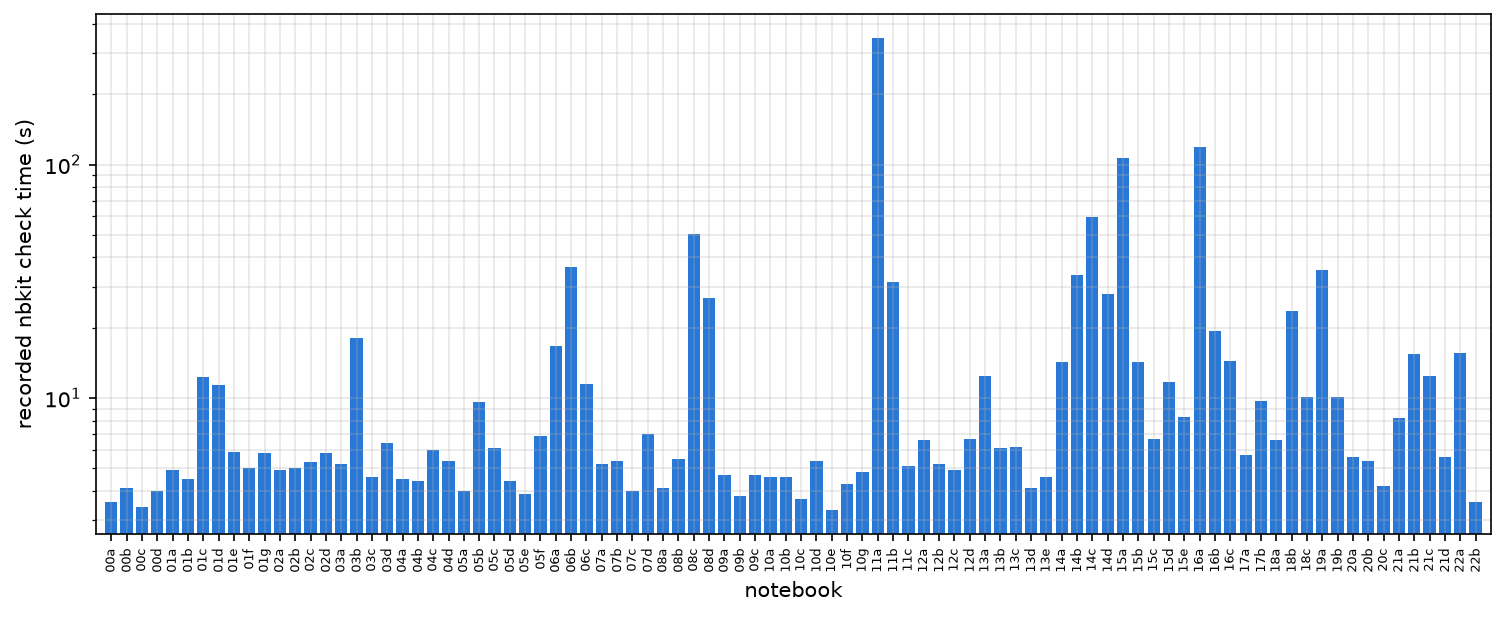

Figure 23a.1 saved as Revision/textbook/figures/23a_1_check_time_per_notebook.png


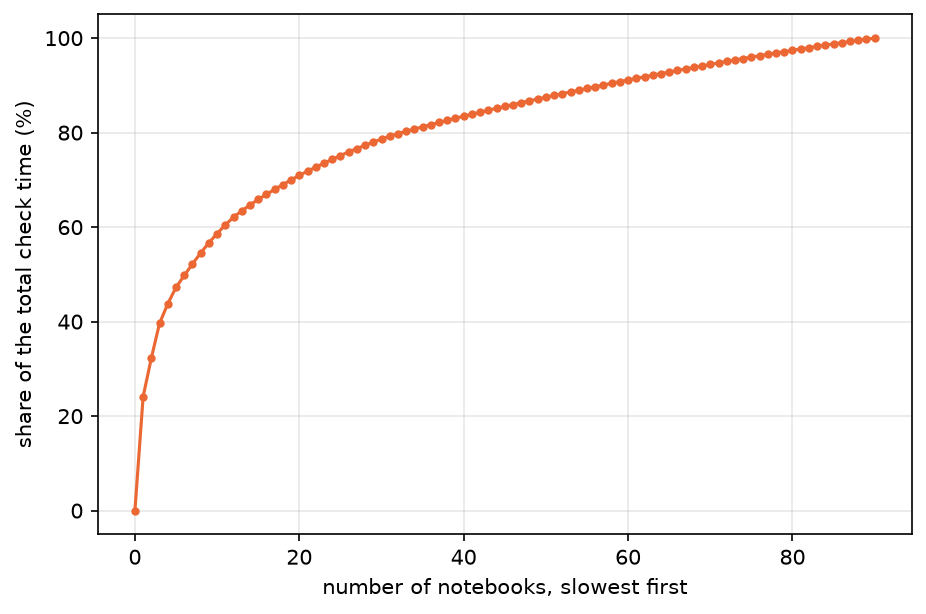

Figure 23a.2 saved as Revision/textbook/figures/23a_2_cumulative_check_time.png
RESULT share of the three slowest notebooks = 39.7 %


In [7]:
ids = [row["id"] for row in ROWS]
seconds = [row["seconds"] for row in ROWS]
fig, ax = plt.subplots(figsize=(12, 4.5))
ax.bar(range(len(ROWS)), seconds, color="#2a78d6")
ax.set_yscale("log")  # equal steps on the axis are equal factors
ax.set_xticks(range(len(ROWS)), ids, rotation=90, fontsize=6)
ax.set_xlim(-1, len(ROWS))
ax.set_xlabel("notebook")
ax.set_ylabel("recorded nbkit check time (s)")
ax.grid(axis="y", which="both", alpha=0.3)
save_figure(fig, "check_time_per_notebook",
            "The wall time in seconds of the last recorded nbkit check of every "
            "notebook of chapters 0 to 22 (one bar each, in book order), on a "
            "logarithmic vertical axis. Most notebooks take a few seconds; a few, "
            "which run the Rust programs or long numerical scans, take minutes.")

slowest = sorted(seconds, reverse=True)
shares = [100 * sum(slowest[:k]) / ALL_SECONDS for k in range(len(slowest) + 1)]
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(range(len(shares)), shares, color="#eb6834", marker="o", markersize=3)
ax.set_xlabel("number of notebooks, slowest first")
ax.set_ylabel("share of the total check time (%)")
ax.grid(alpha=0.3)
save_figure(fig, "cumulative_check_time",
            "The share in percent of the total recorded check time taken by the "
            "slowest notebooks: the curve adds the check times up from the slowest "
            "notebook down. It rises steeply at first, because a few slow notebooks "
            "take a large part of the time, and then flattens.")
report("share of the three slowest notebooks", f"{shares[3]:.1f}", "%")

## 10. Checks, figures and run time per chapter

The next cell draws three bar charts with one bar per chapter: the number of checks,
the number of figures and the recorded check time of its notebooks.

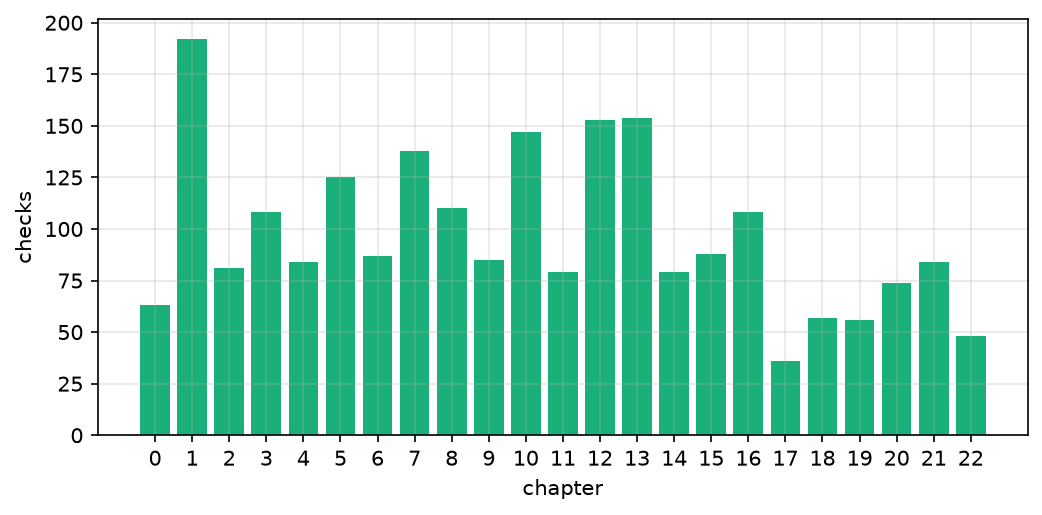

Figure 23a.3 saved as Revision/textbook/figures/23a_3_checks_per_chapter.png


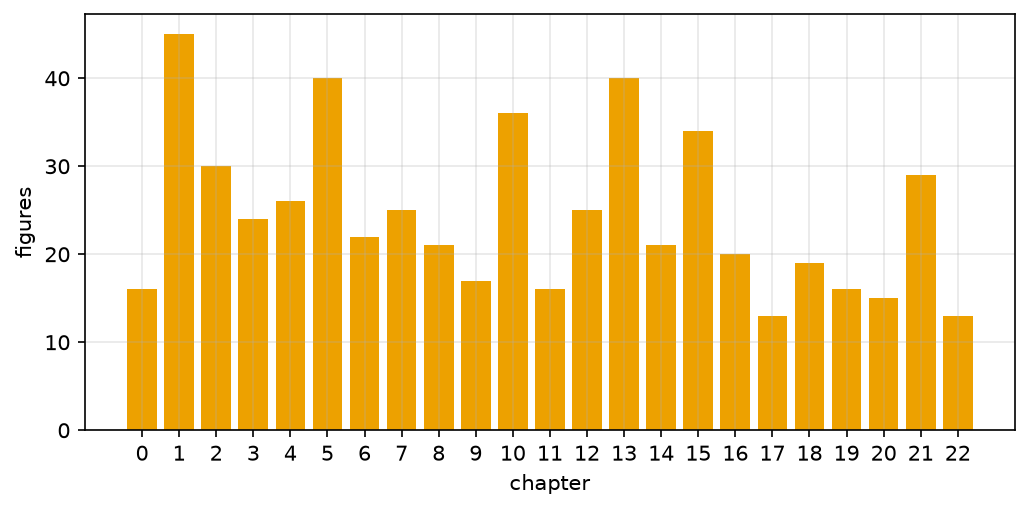

Figure 23a.4 saved as Revision/textbook/figures/23a_4_figures_per_chapter.png


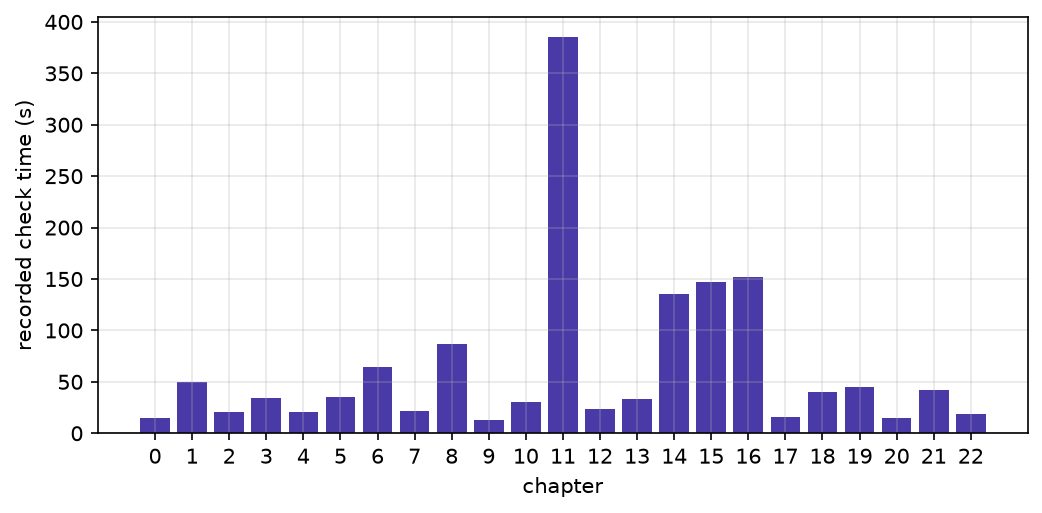

Figure 23a.5 saved as Revision/textbook/figures/23a_5_check_time_per_chapter.png


In [8]:
chapters = sorted(PER_CHAPTER)
for key, name, label, colour, caption in [
        ("checks", "checks_per_chapter", "checks", "#1baf7a",
         "The number of checks of the notebooks of each chapter (the sum of the "
         "numbers n in their last lines ALL n CHECKS PASSED); horizontal axis the "
         "chapter, vertical axis the number of checks."),
        ("figures", "figures_per_chapter", "figures", "#eda100",
         "The number of figures drawn by the notebooks of each chapter (the "
         "entries of their caption files); horizontal axis the chapter, vertical "
         "axis the number of figures."),
        ("seconds", "check_time_per_chapter", "recorded check time (s)", "#4a3aa7",
         "The recorded nbkit check time in seconds of the notebooks of each "
         "chapter, added up; horizontal axis the chapter, vertical axis the "
         "seconds. This is the time one command per chapter needs on the "
         "development machine.")]:
    fig, ax = plt.subplots(figsize=(8, 3.6))
    ax.bar(chapters, [PER_CHAPTER[chapter][key] for chapter in chapters],
           color=colour)
    ax.set_xticks(chapters)
    ax.set_xlabel("chapter")
    ax.set_ylabel(label)
    ax.grid(axis="y", alpha=0.3)
    save_figure(fig, name, caption)

## 11. The steps of the Revision gate

The gate `Revision/verify_revision.sh` holds its steps as a table between the first
and the second appearance of the word `REVISION_GATE_STEPS`. Each line of it has
seven fields separated by `|`: the step name, the expected wall time in seconds, the
kind (`1` = long, skipped by the option `--fast`; `A` = an audit that always runs;
`0` = any other step), a work folder, the output files, the reports and the command.
The next cell reads the table, prints every step with its time and a short form of
its command, and adds up the expected time of the full gate and of `--fast`.

In [9]:
gate = repository_file("Revision/verify_revision.sh").read_text(encoding="utf-8")
table = gate.split("REVISION_GATE_STEPS")[1]  # the text between the two marks
STEPS = [line.split("|") for line in table.splitlines() if line.count("|") == 6]


def short_command(command):
    """What a step runs: the script file for python and wolframscript, else the
    first two words of the command that are not options."""
    words = [word.strip("{}").rsplit("/", 1)[-1] for word in command.split()
             if not word.startswith("-")]
    if words[0] in ("python", "wolframscript"):
        return next(word for word in words[1:] if "." in word)
    return " ".join(words[:2])


print(f"{"step":33} {"sec":>5} {"kind":4} command")
for name, expected, kind, _, _, _, command in STEPS:
    mark = {"1": "long", "A": "all"}.get(kind, "")
    print(f"{name:33} {int(expected):5d} {mark:4} {short_command(command)}")
FULL = sum(int(step[1]) for step in STEPS)
FAST = sum(int(step[1]) for step in STEPS if step[2] != "1")
report("gate steps", len(STEPS))
report("long steps (skipped by --fast)", sum(step[2] == "1" for step in STEPS))
report("expected wall time of the full gate", f"{FULL} s = {FULL / 3600:.2f} h")
report("expected wall time with --fast", f"{FAST} s = {FAST / 60:.1f} min")

step                                sec kind command
algebra-wolfram                      10      verify_algebra.wls
algebra-sympy                         5      check_algebra.py
gkd-rust-build                       60      cargo build
gkd-rust-lovelock                    15      gkd_exe lovelock
gkd-rust-selftest                   900 long gkd_exe gkd-selftest
gkd-wolfram                         110      verify_lovelock_gkd.wls
gkd-sympy                            30      check_lovelock_gkd.py
gkd-notebook-extract                 10      lovelock_extract_nb_inputs.wls
gkd-notebook-digest                   5      lovelock_digest_nb_inputs.py
gkd-notebook-image                   10      lovelock_export_nb_image.wls
gkd-author-extract                  120      extract_author_curvature_outputs.wls
gkd-author-compare                   60      compare_with_author.py
theory-wolfram                     2700 long verify_field_theory.wls
theory-wolfram-scope                 60      verify_scope

The next cell draws the expected wall time of every step of the gate, in the order
in which the gate runs them; the long steps are drawn in a second colour.

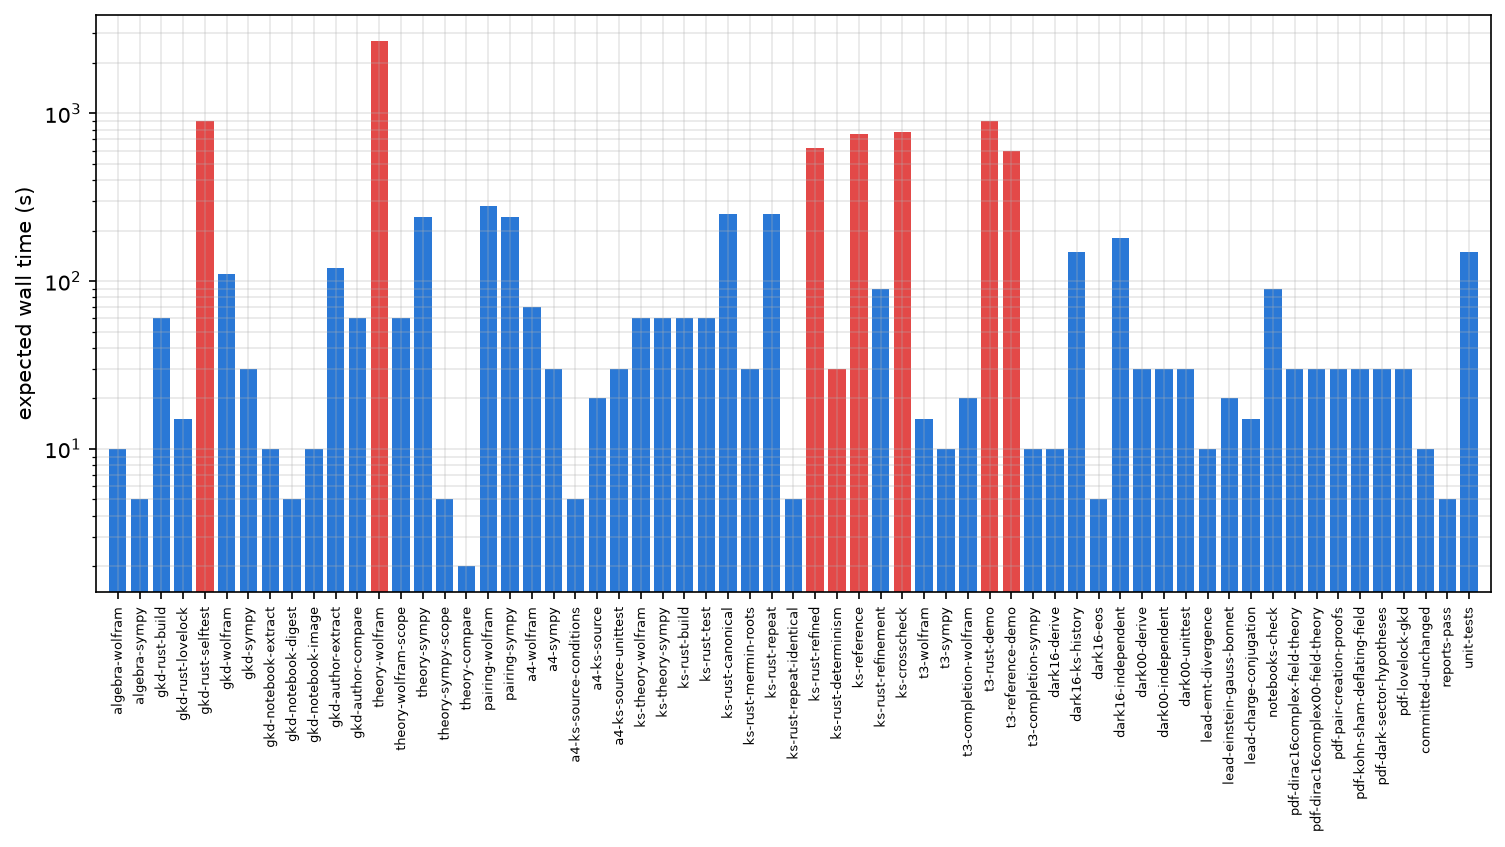

Figure 23a.6 saved as Revision/textbook/figures/23a_6_gate_step_times.png


In [10]:
fig, ax = plt.subplots(figsize=(12, 5))
colours = ["#e34948" if step[2] == "1" else "#2a78d6" for step in STEPS]
ax.bar(range(len(STEPS)), [int(step[1]) for step in STEPS], color=colours)
ax.set_yscale("log")
ax.set_xticks(range(len(STEPS)), [step[0] for step in STEPS], rotation=90,
              fontsize=6)
ax.set_xlim(-1, len(STEPS))
ax.set_ylabel("expected wall time (s)")
ax.grid(axis="y", which="both", alpha=0.3)
save_figure(fig, "gate_step_times",
            "The expected wall time in seconds of every step of the Revision gate, "
            "in the order the gate runs them, on a logarithmic vertical axis; red "
            "bars are the long steps that the option fast skips, blue bars all "
            "others. A few long Wolfram and Kohn-Sham steps take most of the time.")

## 12. The index of the checks of the Revision record

A report is any JSON file of the Revision record (outside the textbook folder and
the Rust build folders) whose top level holds a list `checks` of named checks with
verdicts, a table `checks` of named checks (each `true` or a table with `passed` or
a verdict), or, for the GKD self-test, a list `results` of cases each with a number
of `mismatches`. This is the rule of the gate's step `reports-pass`. The next cell
defines a function that turns one such file into a list of (check name, verdict),
reads every JSON file of the record, and keeps the reports.

In [11]:
def check_list(document):
    """The (name, verdict) pairs of a report, or [] if it is not a report."""
    if not isinstance(document, dict):
        return []
    checks, results = document.get("checks"), document.get("results")
    if isinstance(checks, list):
        return [(item["name"], str(item["verdict"]).upper()) for item in checks]
    if isinstance(checks, dict) and all(isinstance(item, (bool, dict))
                                        for item in checks.values()):
        return [(name, "PASS" if item is True or (isinstance(item, dict) and (
            item.get("passed") is True or
            str(item.get("verdict", "")).upper() == "PASS")) else "FAIL")
            for name, item in checks.items()]
    if isinstance(results, list) and results and all(
            isinstance(item, dict) and "mismatches" in item for item in results):
        return [(", ".join(f"{key}={value}" for key, value in item.items()
                           if key != "mismatches"),
                 "PASS" if item["mismatches"] == 0 else "FAIL") for item in results]
    return []


REPORTS = {}  # report path -> list of (check name, verdict)
for path in by_name(repository_file("Revision").rglob("*.json")):
    relative = path.relative_to(REPO).as_posix()
    if relative.startswith("Revision/textbook/") or "/target/" in relative:
        continue
    pairs = check_list(json.loads(path.read_text(encoding="utf-8")))
    if pairs:
        REPORTS[relative] = pairs
gate_reports = {path for step in STEPS for path in step[5].split(",") if path != "-"}
say(f"{len(REPORTS)} reports found with {sum(map(len, REPORTS.values()))} checks; "
    f"the gate's step table names {len(gate_reports)} reports.")
check(gate_reports <= set(REPORTS),
      "every report named in the gate's step table is in the index")
check(all(verdict in ("PASS", "NOT-AVAILABLE")
          for pairs in REPORTS.values() for _, verdict in pairs),
      "every check of every report is PASS or NOT-AVAILABLE")

39 reports found with 1208 checks; the gate's step table names 39 reports.
PASS every report named in the gate's step table is in the index
PASS every check of every report is PASS or NOT-AVAILABLE


The next cell finds the chapters that cite each check. It cuts every chapter of
chapters 0 to 22 into paragraphs (blocks of lines between empty lines), adds the
output of every code cell of the chapter's notebooks as further blocks, and marks a
check as cited by the chapter when one block contains both the file name of the
check's report and the check's name as a whole word.

In [12]:
BLOCKS = {}  # chapter number -> its paragraphs and the outputs of its notebooks
for chapter in CHAPTERS:
    number = int(chapter.name[:2])  # the chapter number, e.g. 5
    text = chapter.read_text(encoding="utf-8")
    blocks = [block for block in re.split(r"\n\s*\n", text) if block.strip()]
    for row in ROWS:
        if row["chapter"] == number:
            notebook = json.loads((NOTEBOOKS / f"{row["name"]}.ipynb").read_text(
                encoding="utf-8"))
            for cell in notebook["cells"]:
                outputs = [output.get("text", "") for output in cell.get("outputs", [])]
                blocks.append("".join("".join(item) for item in outputs))
    BLOCKS[number] = blocks

CITED = {}  # (report, check name) -> set of chapter numbers
for number, blocks in BLOCKS.items():
    for block in blocks:
        for report_path, pairs in REPORTS.items():
            if report_path.rsplit("/", 1)[1] not in block:
                continue
            for check_name, _ in pairs:
                word = r"(?<![\w.-])" + re.escape(check_name) + r"(?![\w-])"
                if re.search(word, block):
                    CITED.setdefault((report_path, check_name), set()).add(number)
say(f"{len(CITED)} (report, check) pairs are cited by at least one chapter.")

711 (report, check) pairs are cited by at least one chapter.


The next cell prints one line per report: its path (under `Revision/`, without
`.json`), its number of checks, how many are PASS, how many NOT-AVAILABLE, and how
many are cited by at least one chapter. It then writes the complete index, one row
per check, to the data file `Revision/textbook/data/23a_check_index.csv`, reads the
file back and checks that it has one row per check.

In [13]:
print(f"{"report (under Revision/, without .json)":63} {"checks":>6} {"PASS":>4} "
      f"{"N/A":>3} {"cited":>5}")
INDEX = []  # one row per check: report, check, verdict, citing chapters
for report_path, pairs in REPORTS.items():
    for check_name, verdict in pairs:
        chapters = sorted(CITED.get((report_path, check_name), set()))
        INDEX.append([report_path, check_name, verdict,
                      " ".join(str(chapter) for chapter in chapters)])
    short = report_path.removeprefix("Revision/").removesuffix(".json")
    print(f"{short:63} {len(pairs):6d} "
          f"{sum(verdict == "PASS" for _, verdict in pairs):4d} "
          f"{sum(verdict == "NOT-AVAILABLE" for _, verdict in pairs):3d} "
          f"{sum((report_path, name) in CITED for name, _ in pairs):5d}")

CHECK_INDEX = "Revision/textbook/data/23a_check_index.csv"
with output_file(CHECK_INDEX).open("w", encoding="utf-8", newline="") as handle:
    writer = csv.writer(handle, lineterminator="\n")
    writer.writerow(["report", "check", "verdict", "cited_by_chapters"])
    writer.writerows(INDEX)
with output_file(CHECK_INDEX).open(encoding="utf-8", newline="") as handle:
    read_back = list(csv.reader(handle))
report("reports", len(REPORTS))
report("checks in the index", len(INDEX))
report("checks cited by at least one chapter", sum(bool(row[3]) for row in INDEX))
check(read_back[1:] == INDEX, "the index file holds exactly one row per check")

report (under Revision/, without .json)                         checks PASS N/A cited
algebra/reports/python-algebra                                      35   35   0    35
algebra/reports/wolfram-algebra                                     45   45   0    44
dark_sector/dirac16complex/reports/derivation-checks                30   30   0    16
dark_sector/dirac16complex/reports/eos-checks                       13   13   0     5
dark_sector/dirac16complex/reports/independent-checks                9    9   0     2
dark_sector/dirac16complex/reports/ks-history-run                    5    5   0     2
dark_sector/dirac16complex00/reports/python-derive-eos              49   49   0    13
dark_sector/dirac16complex00/reports/python-independent-numerics     28   28   0     1
field_equations_a4/ks_source/reports/ks-source-a4                   23   23   0     7
field_equations_a4/reports/ks-source-conditions                      5    5   0     5
field_equations_a4/reports/python-a4-report          

As an example of the index, the next cell prints the rows of one report: the twelve
checks of the charge-conjugation matrices and the local U(1) law,
`Revision/lead_checks/reports/charge-conjugation-and-u1.json`, with the chapters
that cite each check.

In [14]:
EXAMPLE = "Revision/lead_checks/reports/charge-conjugation-and-u1.json"
print(f"{"check":44} {"verdict":7} cited by chapters")
for report_path, check_name, verdict, chapters in INDEX:
    if report_path == EXAMPLE:
        print(f"{check_name:44} {verdict:7} {chapters or "-"}")
check(sum(row[0] == EXAMPLE for row in INDEX) == 12,
      "the example report holds 12 checks",
      record=f"{EXAMPLE}, all checks")

check                                        verdict cited by chapters
representation_real                          PASS    0 5 7 18 21
B_imaginary_hermitian                        PASS    0 5 7 21
intertwiners_same_mass                       PASS    0 5 7 18 21
intertwiners_reversed_mass                   PASS    0 5 7 18 21
charge_conjugation_matrix_plus               PASS    0 5 7 18 20 21 22
charge_conjugation_matrix_minus              PASS    0 5 7 18 20 21 22
majorana_conditions_consistent               PASS    0 5 7 21
bilinears_under_charge_conjugation           PASS    0 5 7 18 21
quantum_charge_conjugation_unitary_type      PASS    0 5 7 10 18 20 21 22
real_fields_charge_conjugation               PASS    0 5 7 18 20 21 22
spinor_connection_real                       PASS    0 5 7 21
u1_noether_matrix_identity                   PASS    0 5 10 18 20 21 22
PASS the example report holds 12 checks
     reproduces Revision/lead_checks/reports/charge-conjugation-and-u1.json, all che

## 13. Re-running every notebook (only with BOOK_RERUN_ALL=1)

The next cell does nothing but print one sentence, unless the environment variable
`BOOK_RERUN_ALL` is `1`. Then it runs `nbkit check` on the builder of every other
notebook, at most 8 at a time (half the processor threads, when that is fewer),
the slowest first, into a new scratch folder in the system's temporary folder. It
never changes a file of the repository. It prints, per chapter, how many notebooks
passed and their fresh and recorded seconds, every notebook that failed, the wall
time of the whole re-run, and writes the fresh results to `fresh_results.csv` in the
scratch folder; it stops with an error if any notebook failed. The figures above
keep showing the RECORDED times.

In [15]:
RERUN = os.environ.get("BOOK_RERUN_ALL") == "1"  # the switch of this section
if not RERUN:
    say("BOOK_RERUN_ALL is not set to 1, so no other notebook was re-run: every "
        "table and figure above shows the RECORDED results of the provenance files.")
else:
    import subprocess  # starts other programs
    import sys  # sys.executable is the Python program of this notebook
    import tempfile  # makes a new folder in the system's temporary folder
    import time  # a clock, for the wall time of the re-run
    from concurrent.futures import ThreadPoolExecutor  # several at a time

    scratch = Path(tempfile.mkdtemp(prefix="book_rerun_"))
    environment = {key: value for key, value in os.environ.items()
                   if key not in ("BOOK_RERUN_ALL", "TEXTBOOK_OUTPUT_ROOT")}
    nbkit = str(repository_file("Revision/textbook/tools/nbkit.py"))

    def rerun(row):
        """Run nbkit check on the builder of one notebook; keep its key lines."""
        done = subprocess.run(
            [sys.executable, nbkit, "check", str(repository_file(row["builder"])),
             "--scratch", str(scratch)], capture_output=True, text=True,
            encoding="utf-8", errors="replace", cwd=REPO, env=environment)
        values = dict(line.split("=", 1) for line in done.stdout.splitlines()
                      if "=" in line)
        fresh = values.get(f"check_{row["id"]}_seconds", "")
        return {"id": row["id"], "chapter": row["chapter"],
                "result": values.get(f"check_{row["id"]}", "FAILED"),
                "seconds": float(fresh) if fresh[:1].isdigit() else 0.0,
                "recorded": row["seconds"]}

    workers = max(1, min(8, (os.cpu_count() or 2) // 2))
    start = time.perf_counter()
    with ThreadPoolExecutor(max_workers=workers) as pool:
        FRESH = list(pool.map(rerun, sorted(ROWS, key=lambda row: -row["seconds"])))
    wall = time.perf_counter() - start
    FRESH.sort(key=lambda item: item["id"])
    print("chapter notebooks passed  fresh s recorded s")
    for chapter in sorted(PER_CHAPTER):
        items = [item for item in FRESH if item["chapter"] == chapter]
        print(f"{chapter:7d} {len(items):9d} "
              f"{sum(item["result"] == "PASSED" for item in items):6d} "
              f"{sum(item["seconds"] for item in items):8.1f} "
              f"{sum(item["recorded"] for item in items):10.1f}")
    failed = [item["id"] for item in FRESH if item["result"] != "PASSED"]
    for item_id in failed:
        say(f"FAILED {item_id}: run its nbkit check alone to see the problem lines")
    with (scratch / "fresh_results.csv").open("w", encoding="utf-8",
                                              newline="") as handle:
        writer = csv.writer(handle, lineterminator="\n")
        writer.writerow(["id", "chapter", "result", "seconds", "recorded"])
        writer.writerows([item[key] for key in ("id", "chapter", "result",
                                                "seconds", "recorded")]
                         for item in FRESH)
    say(f"Re-run of {len(FRESH)} notebooks with {workers} at a time: wall time "
        f"{wall:.0f} s; fresh results in {scratch / "fresh_results.csv"}")
    assert not failed, f"nbkit check failed for {failed}"
    say(f"RERUN all {len(FRESH)} other notebooks passed their nbkit check.")

BOOK_RERUN_ALL is not set to 1, so no other notebook was re-run: every table and figure
    above shows the RECORDED results of the provenance files.


## 14. The last check

The last cell checks that every file this notebook writes exists and prints the
number of checks that passed.

In [16]:
check(all(output_file(path).is_file() for path in
          [f"{FIGURE_FOLDER}/{name}" for name in CAPTIONS]
          + [NOTEBOOK_TABLE, CHECK_INDEX, CAPTION_FILE]),
      "every file this notebook writes exists")
all_checks_passed()

PASS every file this notebook writes exists
ALL 10 CHECKS PASSED (notebook 23a)


## 15. What this notebook showed

- Every other notebook of the book has a builder and a provenance file, is placed
  exactly once in its own chapter, and its last RECORDED nbkit check passed; the
  table gives, for each, its checks, figures, check date, result, seconds and
  section, and the data file `Revision/textbook/data/23a_notebooks.csv` holds it.
- The totals per chapter and the six figures show where the checks, the figures
  and the run time of the book are.
- The gate of the Revision record has the steps printed in Section 11, with their
  expected wall times; the full gate and the option `--fast` are added up.
- Every check of every report of the Revision record is PASS or NOT-AVAILABLE; the
  index of all of them, with the chapters that cite each, is in
  `Revision/textbook/data/23a_check_index.csv`.
- By default nothing was re-run: the results are the RECORDED ones. With
  `BOOK_RERUN_ALL=1` the last computing section re-runs every other notebook.